## Assignment 5


In [6]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, clear_output, display, Math
import time

In [7]:
# --------------------------
# Constants and known values
# --------------------------
g = 9.81  # gravitational acceleration (m/s^2)
viscosity = 1e-6  # kinematic viscosity of water (m^

### Question 1
First consider laminar Poisuille flow. Demonstrate that the solution (2.44) satisfies the reduced Navier-Stokes equation written in terms of the hydraulic gradient i.e. Ig + viscosity * ∂^2 u/∂y^2 = 0. Derive a solution for the maximum velocity at the centerline uc=u(y=a/2). Plot the dimensionless velocity profile i.e. plot u/uc versus y/a. Additionally, plot the dimensionless vorticity profile i.e. 2*omega_3*viscosity/(gIa) vs. y/a

In [8]:
# Define symbolic variables
I, g, viscosity, y, a, yoa = sp.symbols('I g nu y a yoa')

# Velocity profile (Eq. 2.44)
u = I * g / (2 * viscosity) * (a * y - y**2)

# Reduced Navier-Stokes equation
eq1 = viscosity * sp.diff(u, y, 2) + I * g
#Q1_check = sp.simplify(eq1)   # should simplify to 0

In [9]:
# See visually the formulas 

# Formula from 2.44
print("Velocity profile u(y):")
display(Math(sp.latex(u)))

# Formula from reduced Navier-Stokes equation
print("\nReduced Navier-Stokes equation:")
display(Math(sp.latex(eq1)))

Velocity profile u(y):


<IPython.core.display.Math object>


Reduced Navier-Stokes equation:


<IPython.core.display.Math object>

In [10]:
# Maximum velocity at centerline
u_c = u.subs(y, a/2)                    # in equation u, change all y to a/2

# Dimensionless velocity profile u/u_c
uou_c_expr = sp.simplify(u.subs(y, yoa*a) / u_c)

vor = -sp.diff(u, y)
dimless_vor_expr = sp.simplify(vor.subs(y, yoa*a) * viscosity / (g * I * a))


print("Maximum velocity at centerline u_c:")
display(Math(sp.latex(u_c)))
print("\nVorticity:")
display(Math(sp.latex(vor)))
print("\nDimensionless vorticity profile:")
display(Math(sp.latex(dimless_vor_expr)))

Maximum velocity at centerline u_c:


<IPython.core.display.Math object>


Vorticity:


<IPython.core.display.Math object>


Dimensionless vorticity profile:


<IPython.core.display.Math object>

In [11]:
# Convert symbolic expressions to numerical functions so they can be evaluated and calculated
uou_c_func = sp.lambdify((yoa, I, g, viscosity, a), uou_c_expr, 'numpy')
dimless_vor_func = sp.lambdify((yoa, I, g, viscosity, a), dimless_vor_expr, 'numpy')

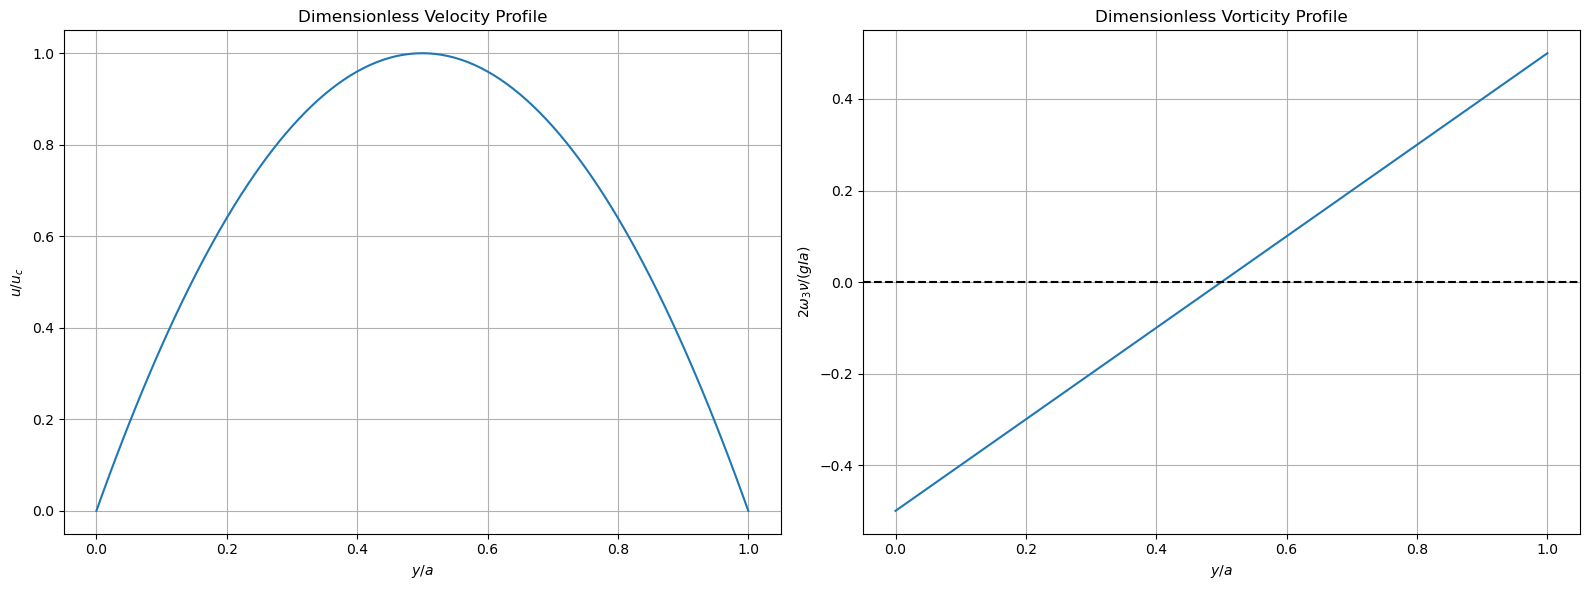

In [12]:
# Parameters for plotting
I_val, g_val, viscosity_val, a_val = 1.0, 9.81, 1e-6, 1.0
yoa_vals = np.linspace(0, 1, 101)

# Evaluate functions
uou_c_vals = uou_c_func(yoa_vals, I_val, g_val, viscosity_val, a_val)
dimless_vor_vals = dimless_vor_func(yoa_vals, I_val, g_val, viscosity_val, a_val)

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(yoa_vals, uou_c_vals)
axs[0].set_xlabel(r'$y/a$')
axs[0].set_ylabel(r'$u/u_c$')
axs[0].set_title('Dimensionless Velocity Profile')
axs[0].grid(True)

axs[1].plot(yoa_vals, dimless_vor_vals)
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_xlabel(r'$y/a$')
axs[1].set_ylabel(r'$2\omega_3 \nu / (gIa)$')
axs[1].set_title('Dimensionless Vorticity Profile')
axs[1].grid(True)

plt.tight_layout()
plt.show()


### Question 2
Now consider the laminar flow above above an oscillating plate. Demonstrate that the analytical
solution derived in class satisfies the reduced Navier-Stokes equation (2.47). Animate the solution over
a period i.e. animate u/u0 versus y/δ

In [19]:
# -------------------------------------------------
# Symbolic definitions
# -------------------------------------------------
u0, y, delta, omega, t, nu, yodelta, omegat = sp.symbols('u0 y delta omega t nu yodelta omegat')

# Analytical solution for oscillatory boundary layer (Stokes' second problem)
u = u0 * sp.exp(-y/delta) * sp.cos(omega*t - y/delta)

# Reduced Navier-Stokes equation (2.47): ∂u/∂t = ν ∂²u/∂y²
eq2 = sp.diff(u, t) - nu * sp.diff(u, y, 2)

# Stokes length relation δ = sqrt(2ν/ω)
eq3 = sp.Eq(delta, sp.sqrt(2*nu/omega))
delta_expr = sp.solve(eq3, delta)[0]

# Check that analytical solution satisfies reduced NS equation
Q2_check = sp.simplify(eq2.subs(delta, delta_expr))
print("Check of reduced NS equation (should be 0):", Q2_check)

# Dimensionless velocity profile u/u0 in terms of y/δ and ωt
u_ratio_expr = sp.simplify(
    (u.subs({y: yodelta*delta_expr, t: omegat/omega, delta: delta_expr}) / u0)
)

# Convert symbolic expression to numerical function (real part only)
u_ratio_func = sp.lambdify((yodelta, omegat, nu, omega), sp.re(u_ratio_expr), 'numpy')

# -------------------------------------------------
# Numerical evaluation
# -------------------------------------------------
nu_val = 1e-6        # [m^2/s]
omega_val = 2*np.pi  # rad/s (period = 1 s)

yodelta_vals = np.linspace(0, 5, 200)        # dimensionless y/δ
omegat_vals = np.linspace(0, 2*np.pi, 120)   # dimensionless ωt

# Precompute profiles
u_profiles = np.zeros((len(yodelta_vals), len(omegat_vals)))
for j, ot in enumerate(omegat_vals):
    u_profiles[:, j] = u_ratio_func(yodelta_vals, ot, nu_val, omega_val)

# -------------------------------------------------
# Animation setup
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
line, = ax.plot([], [], color='blue', lw=2)
ax.axvline(0, color='k', linestyle='--')
ax.set_xlim([-1, 1])
ax.set_ylim([0, 5])
ax.set_xlabel(r'$u/u_0$', fontsize=12)
ax.set_ylabel(r'$y/\delta$', fontsize=12)
ax.grid(True)
title = ax.set_title('')

# Initialization function
def init():
    line.set_data([], [])
    title.set_text('')
    return line, title

# Update function for each frame
def update(frame):
    line.set_data(u_profiles[:, frame], yodelta_vals)
    title.set_text(r'$\omega t = %.2f$' % omegat_vals[frame])
    return line, title

# Create animation
max_frames = len(omegat_vals)
anim = animation.FuncAnimation(
    fig, update, frames=max_frames, init_func=init,
    interval=100, blit=False
)

plt.close(fig)  # Prevent static plot in notebooks

# Display as HTML animation
HTML(anim.to_jshtml())

Check of reduced NS equation (should be 0): 0
